# Notebook 07 — Explainability + Final Visualizations

**Purpose:** Open the black box. Apply SHAP (SHapley Additive exPlanations) to the best regression model from Notebook 06 (XGBoost on Set C) and answer the project's deepest analytical questions:

1. **Which features drive property value predictions globally?** Does the SHAP ranking match the Spearman correlation ranking from Notebook 04?
2. **Is the subway-vs-cafe confounding from EDA actually disentangled by the model?** SHAP can attribute partial effects; correlation cannot.
3. **How much do the cluster features contribute?** This is the SHAP-level evidence for the ablation finding that Set C > Set A.
4. **Why does the model predict specific buildings the way it does?** Local SHAP waterfall plots for three representative buildings.

**Inputs:**
- `outputs/models/best_regression_model.joblib` — XGBoost on Set C (from Notebook 06)
- `data/processed/brooklyn_clustered.parquet` — full feature matrix

**Outputs:**
- `outputs/figures/explainability/*.png` — SHAP summary, dependence, waterfall plots
- `outputs/figures/explainability/07_final_value_map.html` — interactive Folium map
- Final project insights summary (markdown) for the report's Discussion section

**Author:** Delfin Aksu

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import shap

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

RANDOM_SEED = 42

c:\Users\Delfin AKSU\anaconda3\envs\urban-ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path('..').resolve()
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'explainability'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'FIGURE_DIR:   {FIGURE_DIR}')

PROJECT_ROOT: C:\Users\Delfin AKSU\Desktop\urban-building-ml
FIGURE_DIR:   C:\Users\Delfin AKSU\Desktop\urban-building-ml\outputs\figures\explainability


## 2. Load Best Model + Data

In [3]:
best = joblib.load(MODEL_DIR / 'best_regression_model.joblib')
print(f'Model:        {best["model_name"]}')
print(f'Feature set:  {best["feature_set"]}')
print(f'CV R²:        {best["cv_r2_mean"]:.4f}')
print(f'CV RMSE:      {best["cv_rmse_mean"]:.4f}')
print(f'CV MAE:       {best["cv_mae_mean"]:.4f}')
print(f'# Features:   {len(best["feature_list"])}')

model = best['model']
feature_list = best['feature_list']

df = pd.read_parquet(PROCESSED_DATA_DIR / 'brooklyn_clustered.parquet')
df['log_assesstot'] = np.log1p(df['assesstot'])
print(f'\nDataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

Model:        XGBoost
Feature set:  C
CV R²:        0.9415
CV RMSE:      0.2670
CV MAE:       0.1924
# Features:   44

Dataset: 265,507 rows x 59 columns


### 2.1 Prepare feature matrix in same column order as training

In [4]:
# Re-derive landuse one-hot dummies (same as Notebook 06 did)
landuse_dummies = pd.get_dummies(df['landuse'], prefix='lu', dummy_na=False).astype(int)
df_full = pd.concat([df, landuse_dummies], axis=1)
# Some landuse one-hot columns may already exist in df_full from earlier merges; drop duplicates
df_full = df_full.loc[:, ~df_full.columns.duplicated()]

# Verify all feature_list columns exist
missing = [c for c in feature_list if c not in df_full.columns]
assert not missing, f'Missing features: {missing}'
print(f'All {len(feature_list)} feature columns present.')

X_full = df_full[feature_list].astype(np.float32).values
print(f'Feature matrix shape: {X_full.shape}')

All 44 feature columns present.
Feature matrix shape: (265507, 44)


## 3. SHAP TreeExplainer

**SHAP** (SHapley Additive exPlanations) attributes a prediction to each feature in a game-theoretically consistent way. For tree models like XGBoost, `TreeExplainer` computes SHAP values in **O(TLD²)** time (T = trees, L = leaves, D = depth) — fast enough to run on tens of thousands of buildings.

**Strategy:** sample 10,000 buildings (stratified across clusters so all urban typologies are represented), compute SHAP values, and use these for all global analyses. Local SHAP plots use the full prediction set.

### 3.1 Build the SHAP background sample

In [5]:
rng = np.random.default_rng(seed=RANDOM_SEED)

# Stratified sample: balance representation across clusters
TARGET_SAMPLE = 10_000
cluster_sizes = df_full['cluster_id'].value_counts()
n_per_cluster = max(1, TARGET_SAMPLE // len(cluster_sizes))

sample_indices = []
for cid, size in cluster_sizes.items():
    pool = df_full[df_full['cluster_id'] == cid].index
    take = min(n_per_cluster, size)
    sample_indices.extend(rng.choice(pool, size=take, replace=False).tolist())

sample_indices = np.array(sample_indices)
X_sample = X_full[df_full.index.get_indexer(sample_indices)]
df_sample = df_full.loc[sample_indices]
print(f'SHAP sample: {len(sample_indices):,} buildings')
print(f'Cluster distribution in sample:')
print(df_sample['cluster_id'].value_counts().sort_index().to_frame('n').T)

SHAP sample: 8,338 buildings
Cluster distribution in sample:
cluster_id     0     1     2     3     4  5
n           1666  1666  1666  1666  1666  8


### 3.2 Compute SHAP values

In [6]:
import time
t0 = time.time()

# TreeExplainer is the fast path for XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values computed in {time.time()-t0:.1f}s')
print(f'shap_values shape: {shap_values.shape}')
print(f'  (n_buildings × n_features = {shap_values.shape[0]:,} × {shap_values.shape[1]})')
print(f'expected_value (base prediction): {explainer.expected_value:.4f}')

SHAP values computed in 13.2s
shap_values shape: (8338, 44)
  (n_buildings × n_features = 8,338 × 44)
expected_value (base prediction): 11.7934


## 4. Global SHAP Importance

Two complementary views:
- **Bar plot** of mean |SHAP value| per feature — the ranking of *how much* each feature moves the prediction on average.
- **Dot plot** (beeswarm) — same ranking, but every dot is a building, and dot colour shows the *feature value*. This reveals direction (high feature value → high or low prediction).

### 4.1 Bar plot — mean absolute SHAP per feature

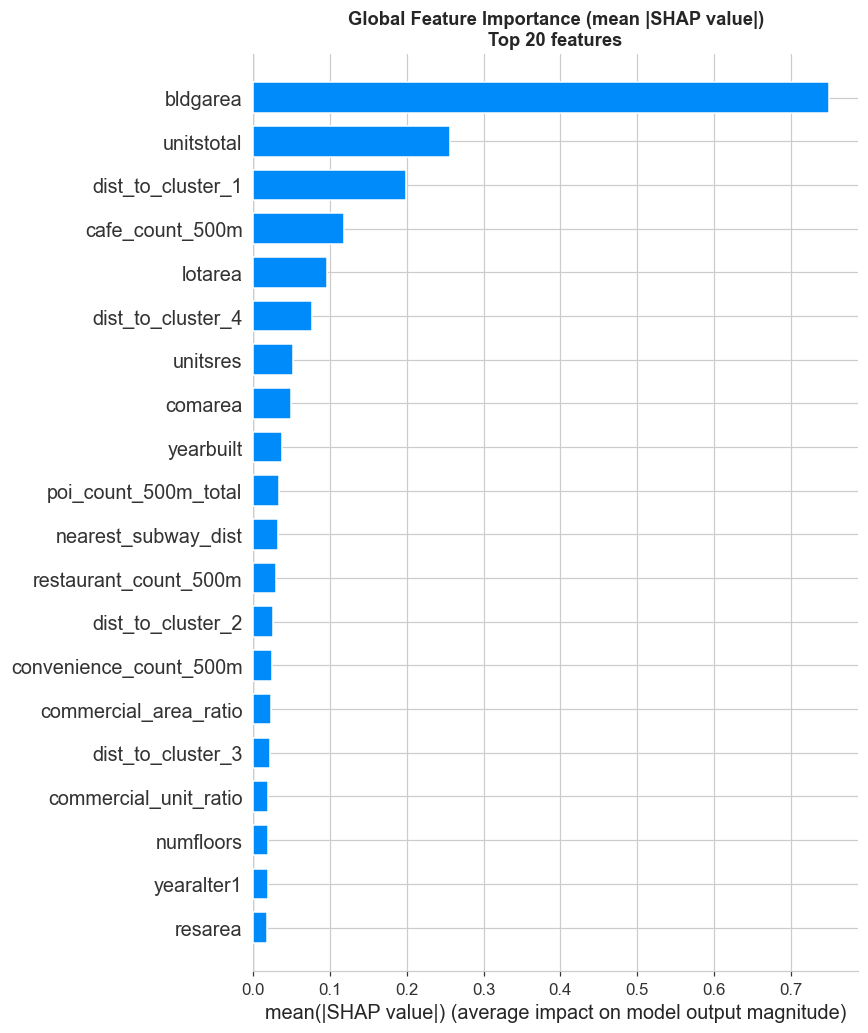

In [7]:
fig = plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, feature_names=feature_list,
                  plot_type='bar', max_display=20, show=False)
plt.title('Global Feature Importance (mean |SHAP value|)\nTop 20 features',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_shap_summary_bar.png')
plt.show()

### 4.2 Dot plot — feature impact distribution

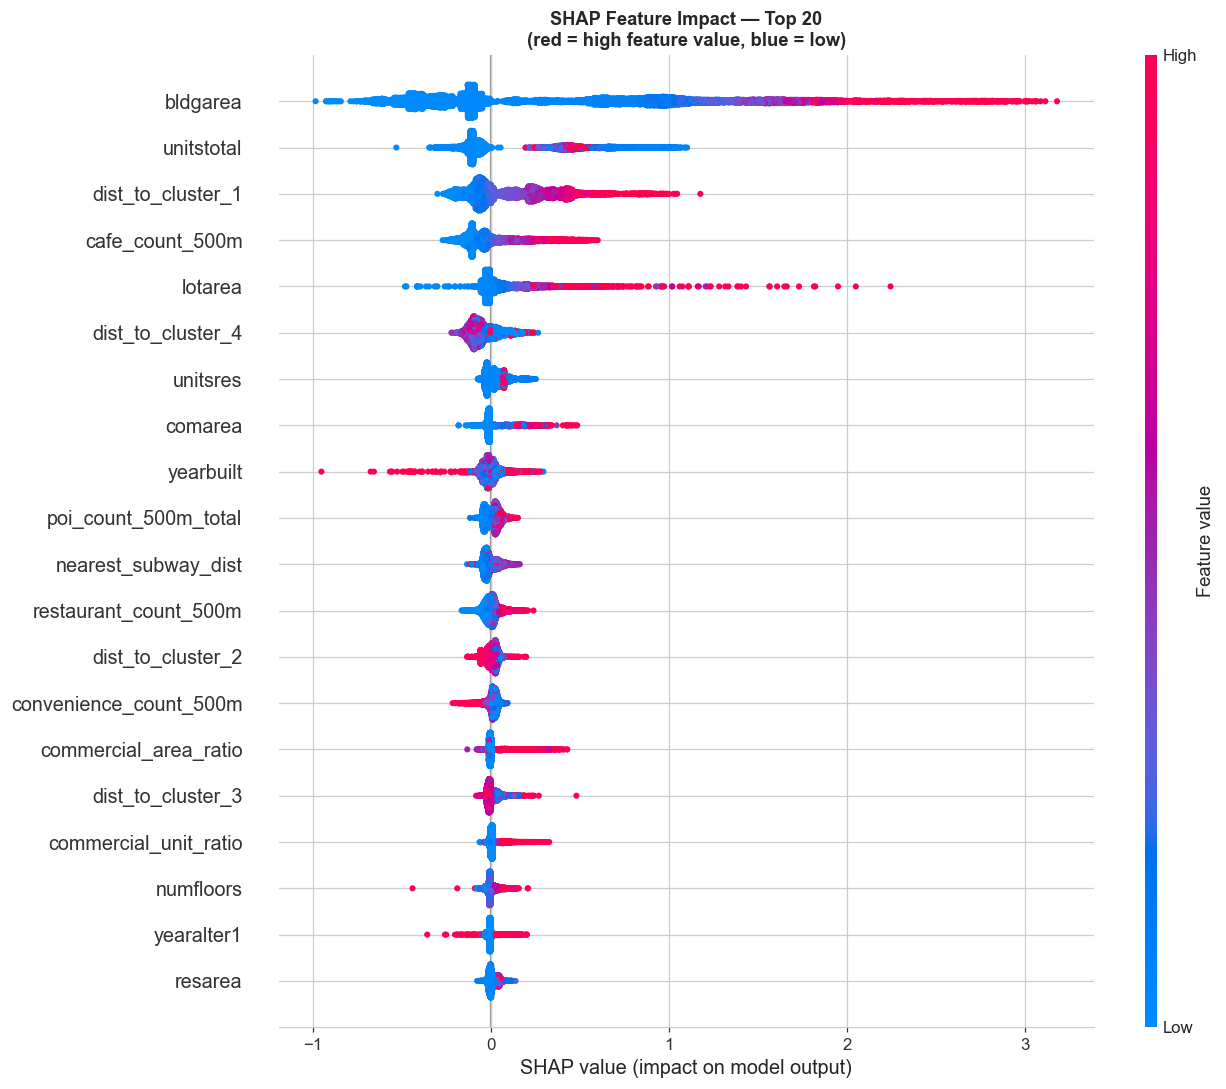

In [8]:
fig = plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, feature_names=feature_list,
                  max_display=20, show=False, plot_size=None)
plt.title('SHAP Feature Impact — Top 20\n(red = high feature value, blue = low)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_shap_summary_dot.png')
plt.show()

### 4.3 Numerical importance ranking

In [9]:
mean_abs = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_list,
    'mean_abs_shap': mean_abs,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
importance_df['rank'] = importance_df.index + 1
importance_df['cumulative_share_%'] = (importance_df['mean_abs_shap'].cumsum() / importance_df['mean_abs_shap'].sum() * 100).round(1)

print('Top 20 features by mean |SHAP|:')
importance_df.head(20)[['rank', 'feature', 'mean_abs_shap', 'cumulative_share_%']]

Top 20 features by mean |SHAP|:


,rank,feature,mean_abs_shap,cumulative_share_%
0,1,bldgarea,0.7503,35.9000
1,2,unitstotal,0.2558,48.2000
2,3,dist_to_cluster_1,0.1994,57.7000
3,4,cafe_count_500m,0.1187,63.4000
4,5,lotarea,0.0957,68.0000
5,6,dist_to_cluster_4,0.0760,71.6000
6,7,unitsres,0.0519,74.1000
7,8,comarea,0.0494,76.5000
8,9,yearbuilt,0.0375,78.3000
9,10,poi_count_500m_total,0.0340,79.9000


## 5. The Subway-vs-Café Confounding Question

Notebook 04 (EDA) showed that **subway accessibility correlates with property value (ρ = -0.38)** but also **correlates strongly with café density (transit-rich areas have 9× more amenities)**. Raw correlations cannot disentangle whether the subway 'effect' is causal or just amenity confounding.

**SHAP dependence plots** can. For a given feature `F`, SHAP shows the partial contribution to predicted value *holding other features constant*. If `nearest_subway_dist` has a large SHAP contribution even when `cafe_count_500m` is also in the model, the subway effect is robust. Otherwise the cafés steal the attribution.

**Hypothesis going in (based on EDA):** café density will dominate (it has the higher Spearman correlation, 0.56 vs 0.38). The model has learned that café count is a better proxy for desirability than raw subway proximity.

### 5.1 SHAP dependence: nearest_subway_dist

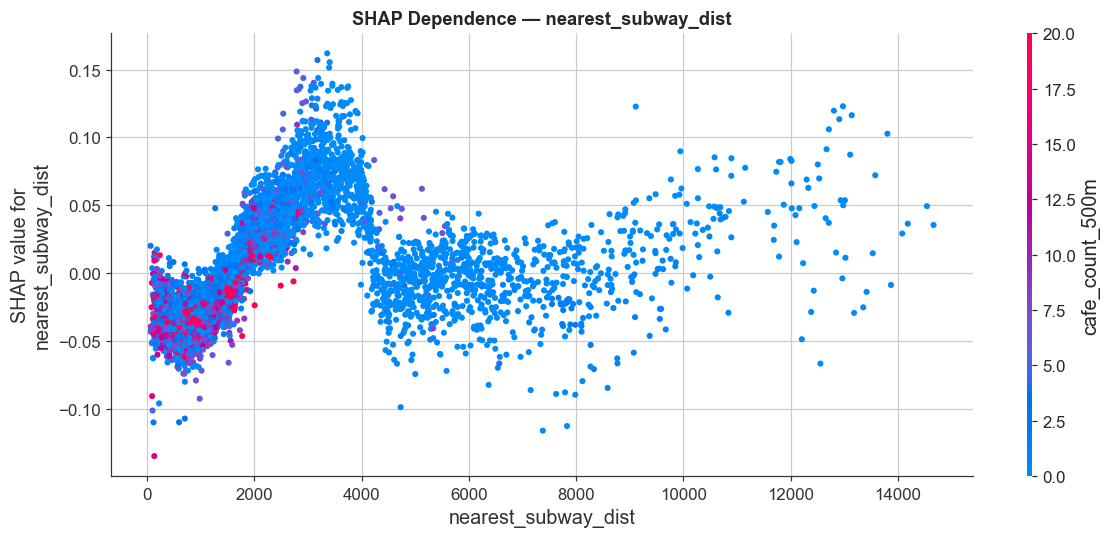

In [10]:
if 'nearest_subway_dist' in feature_list:
    fig, ax = plt.subplots(figsize=(11, 5))
    shap.dependence_plot('nearest_subway_dist', shap_values, X_sample,
                          feature_names=feature_list, ax=ax, show=False,
                          interaction_index='cafe_count_500m')
    ax.set_title('SHAP Dependence — nearest_subway_dist',
                  fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / '07_shap_dep_subway.png')
    plt.show()

### 5.2 SHAP dependence: cafe_count_500m

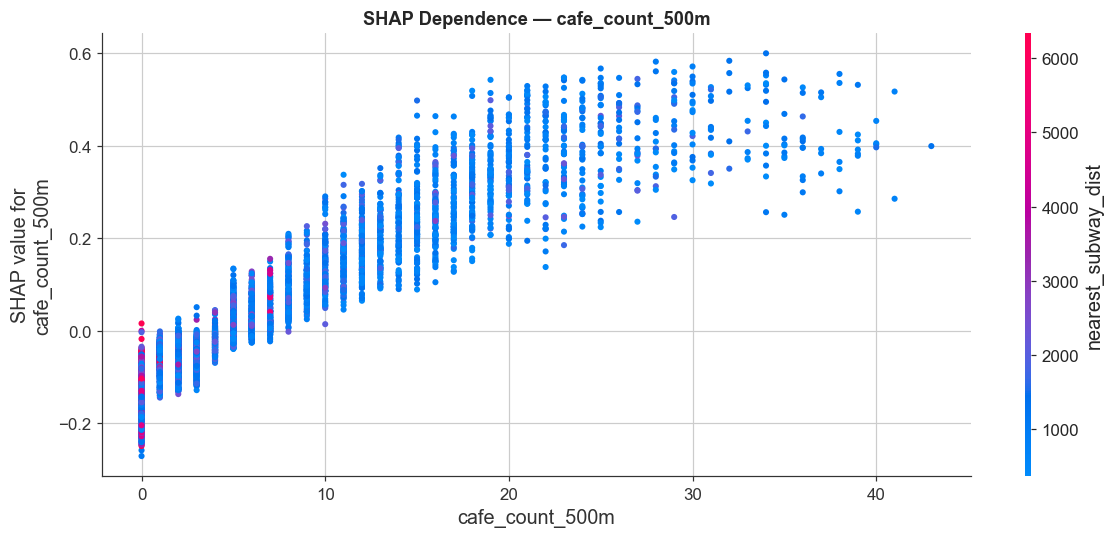

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
shap.dependence_plot('cafe_count_500m', shap_values, X_sample,
                      feature_names=feature_list, ax=ax, show=False,
                      interaction_index='nearest_subway_dist')
ax.set_title('SHAP Dependence — cafe_count_500m', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_shap_dep_cafe.png')
plt.show()

### 5.3 SHAP dependence: bldgarea (the dominant feature)

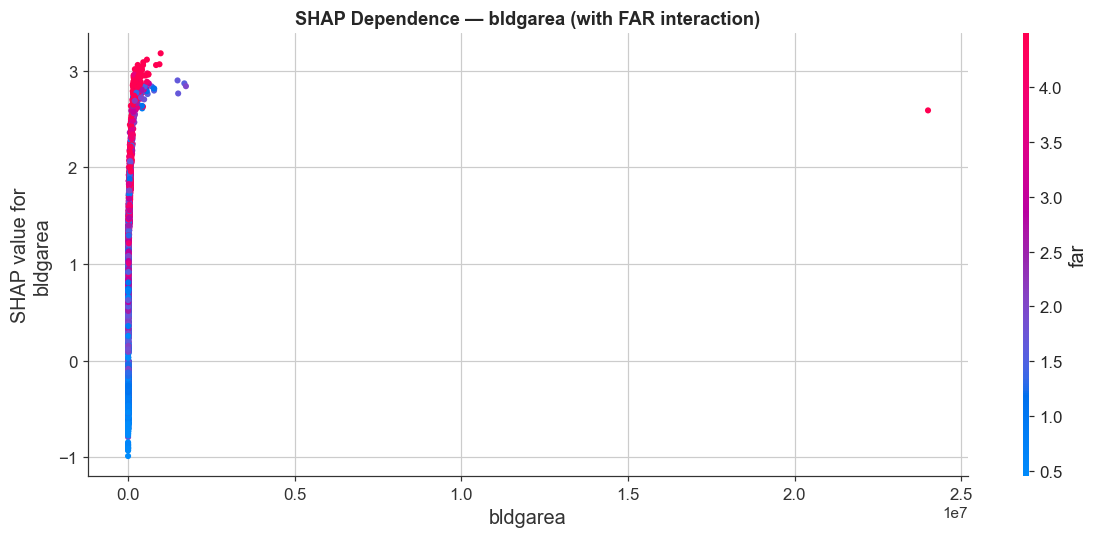

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
shap.dependence_plot('bldgarea', shap_values, X_sample,
                      feature_names=feature_list, ax=ax, show=False,
                      interaction_index='far')
ax.set_title('SHAP Dependence — bldgarea (with FAR interaction)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_shap_dep_bldgarea.png')
plt.show()

## 6. Cluster Feature Contribution

Set C beat Set A by +0.0026 in XGBoost R² (Notebook 06). SHAP gives us **per-feature attribution**: how much of that gain comes from the `dist_to_cluster_*` features?

In [13]:
cluster_features = [f for f in feature_list if f.startswith('dist_to_cluster_') or f.startswith('cluster_')]
cluster_mean_abs = importance_df[importance_df['feature'].isin(cluster_features)]

print(f'Cluster-derived features: {len(cluster_features)}')
print(f'Total cluster contribution: {cluster_mean_abs["mean_abs_shap"].sum():.4f}')
print(f'Sum across all features:    {importance_df["mean_abs_shap"].sum():.4f}')
print(f'Cluster share of total importance: {cluster_mean_abs["mean_abs_shap"].sum() / importance_df["mean_abs_shap"].sum():.2%}')
print()
print('Per-cluster feature ranking:')
cluster_mean_abs[['rank', 'feature', 'mean_abs_shap', 'cumulative_share_%']]

Cluster-derived features: 6
Total cluster contribution: 0.3464
Sum across all features:    2.0888
Cluster share of total importance: 16.58%

Per-cluster feature ranking:


,rank,feature,mean_abs_shap,cumulative_share_%
2,3,dist_to_cluster_1,0.1994,57.7000
5,6,dist_to_cluster_4,0.0760,71.6000
12,13,dist_to_cluster_2,0.0259,84.1000
15,16,dist_to_cluster_3,0.0222,87.4000
20,21,dist_to_cluster_0,0.0169,91.9000
35,36,dist_to_cluster_5,0.0059,99.4000


## 7. Local SHAP — Why this building, this price?

Three representative buildings get their own waterfall plot. Each shows the chain of feature contributions starting from the model's expected value and ending at the actual predicted value.

In [14]:
# Pick three buildings: low value, median, high value (within the SHAP sample)
sample_assesstot = df_sample['assesstot']
low_idx = sample_assesstot.idxmin()
med_idx = sample_assesstot.iloc[(sample_assesstot - sample_assesstot.median()).abs().argsort()[:1]].index[0]
high_idx = sample_assesstot.idxmax()

for tag, idx in [('LOW', low_idx), ('MEDIAN', med_idx), ('HIGH', high_idx)]:
    row = df_sample.loc[idx]
    print(f'{tag}:  bbl={row["bbl"]:.0f}  address={row["address"]}  cluster={row["cluster_name"]}  $={row["assesstot"]:,.0f}')

LOW:  bbl=3043320058  address=801 BARBEY STREET  cluster=Gentrified Walk-Up Residential  $=18,720
MEDIAN:  bbl=3003330008  address=367 CLINTON STREET  cluster=Gentrified Walk-Up Residential  $=277,080
HIGH:  bbl=3048290001  address=451 CLARKSON AVENUE  cluster=Mixed-Use Commercial Corridor  $=145,664,100


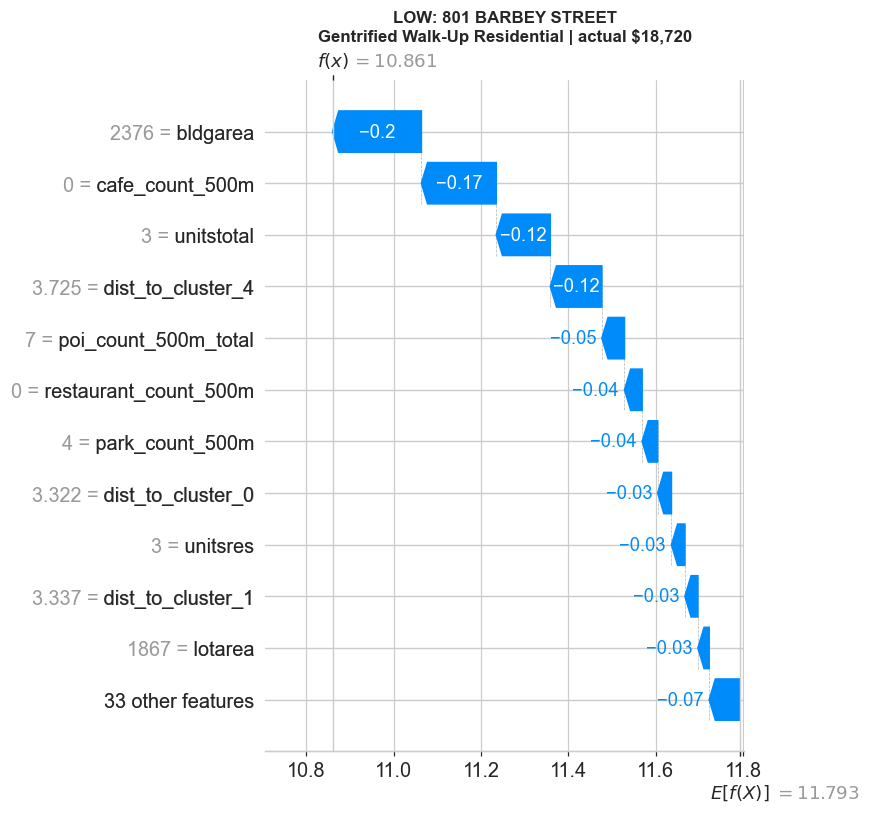

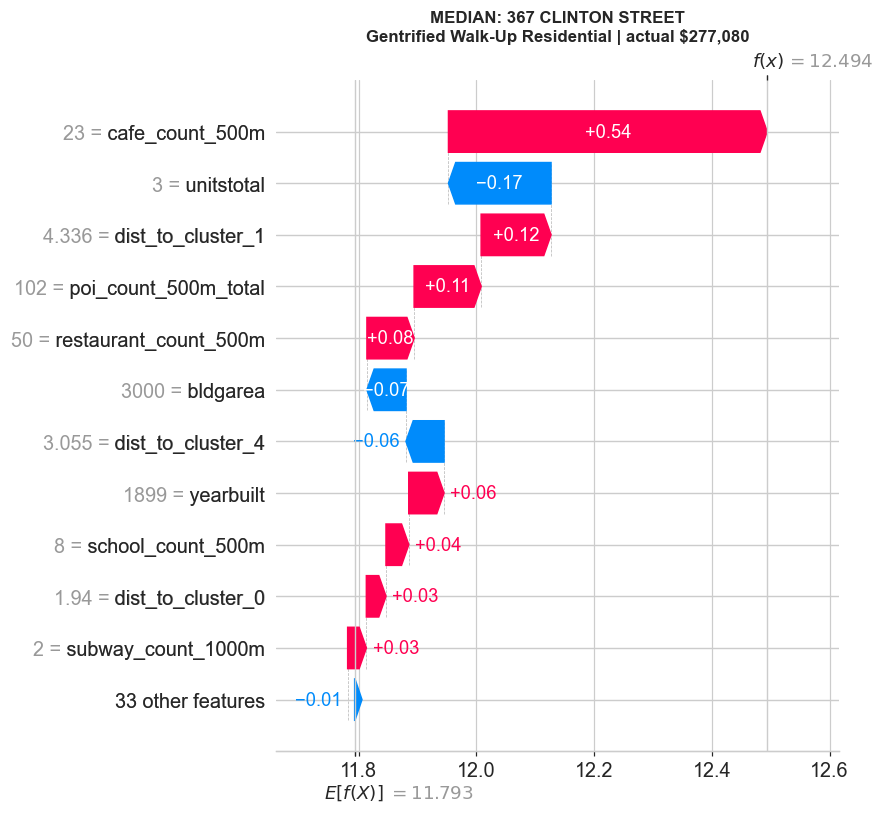

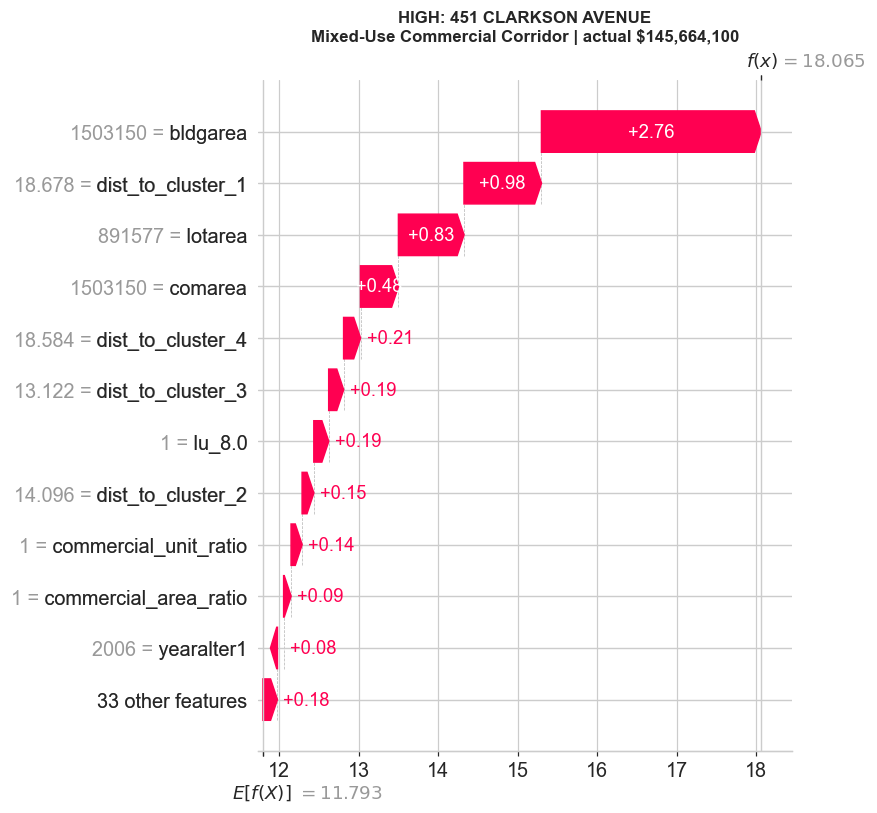

In [15]:
# Render waterfall plots for each
for tag, idx in [('LOW', low_idx), ('MEDIAN', med_idx), ('HIGH', high_idx)]:
    pos = np.where(sample_indices == idx)[0][0]
    expl_obj = shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        data=X_sample[pos],
        feature_names=feature_list,
    )
    fig = plt.figure(figsize=(11, 6))
    shap.plots.waterfall(expl_obj, max_display=12, show=False)
    addr = df_sample.loc[idx, 'address']
    asses = df_sample.loc[idx, 'assesstot']
    cname = df_sample.loc[idx, 'cluster_name']
    plt.title(f'{tag}: {addr}\n{cname} | actual ${asses:,.0f}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'07_shap_waterfall_{tag.lower()}.png')
    plt.show()

## 8. Final Showcase Visualizations

Two final figures that go into the report's Results chapter.

### 8.1 Predicted property-value map (using all 265,507 buildings)

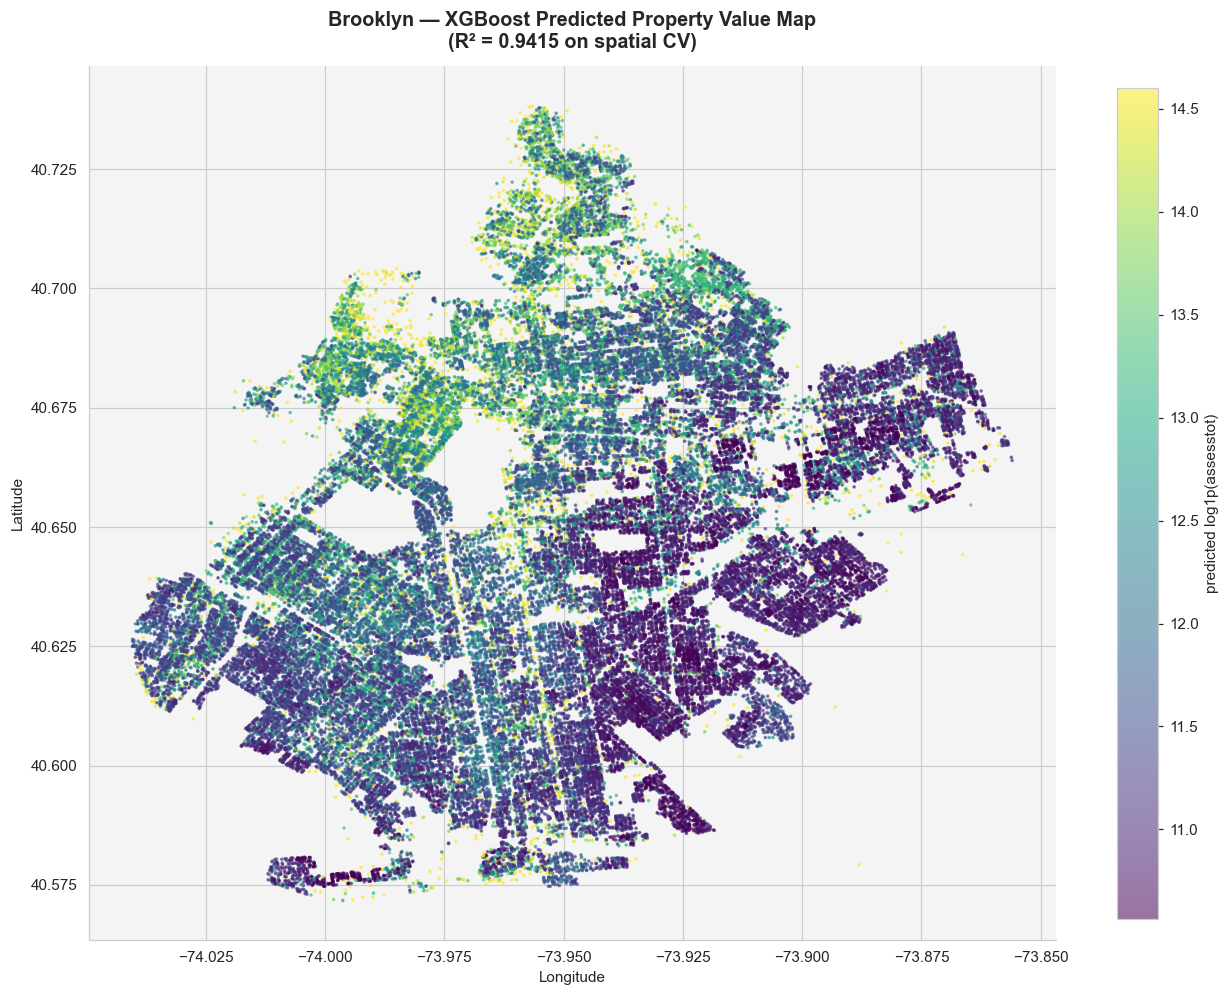

In [16]:
# Generate full predictions on the entire dataset
df_full['log_pred'] = model.predict(X_full)
df_full['pred_assesstot'] = np.expm1(df_full['log_pred'])

fig, ax = plt.subplots(figsize=(12, 10))
rng = np.random.default_rng(seed=RANDOM_SEED)
sample_idx = rng.choice(df_full.index, size=60_000, replace=False)
s = df_full.loc[sample_idx]

sc = ax.scatter(s['longitude'], s['latitude'], c=s['log_pred'],
                cmap='viridis', s=2, alpha=0.55,
                vmin=df_full['log_pred'].quantile(0.02),
                vmax=df_full['log_pred'].quantile(0.98))
plt.colorbar(sc, ax=ax, shrink=0.78, label='predicted log1p(assesstot)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Brooklyn — XGBoost Predicted Property Value Map\n(R² = {best["cv_r2_mean"]:.4f} on spatial CV)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_aspect('equal'); ax.set_facecolor('#f4f4f4')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_final_predicted_value_map.png')
plt.show()

### 8.2 Interactive Folium map (HTML)

In [17]:
import folium
from folium.plugins import HeatMap

# Center on Brooklyn
m = folium.Map(location=[40.65, -73.95], zoom_start=12, tiles='cartodbpositron')

# Add a heatmap of log_pred
heat_sample = df_full.loc[rng.choice(df_full.index, size=20_000, replace=False)]
heat_data = [[r['latitude'], r['longitude'], r['log_pred']] for _, r in heat_sample.iterrows()]
HeatMap(heat_data, radius=8, blur=15, min_opacity=0.3,
        gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1.0: 'red'}).add_to(m)

# Top 5 buildings as markers
top5 = df_full.nlargest(5, 'assesstot')
for _, r in top5.iterrows():
    folium.Marker(
        location=[r['latitude'], r['longitude']],
        popup=f"<b>{r['address']}</b><br>Actual: ${r['assesstot']:,.0f}<br>Predicted: ${r['pred_assesstot']:,.0f}<br>Cluster: {r['cluster_name']}",
        icon=folium.Icon(color='red', icon='star')
    ).add_to(m)

out_html = FIGURE_DIR / '07_final_value_map.html'
m.save(str(out_html))
print(f'Interactive map saved: {out_html}')
print(f'Open in browser to view.')

Interactive map saved: C:\Users\Delfin AKSU\Desktop\urban-building-ml\outputs\figures\explainability\07_final_value_map.html
Open in browser to view.


## 9. Final Project Insights Summary

**A consolidated narrative across all seven notebooks, ready for the report's Discussion / Conclusions chapter.**

### Finding 1 — A custom multi-source urban dataset is feasible and valuable

We composed 265,507 buildings × 43 columns from three public sources (NYC PLUTO 25v4, MTA Subway Stations, OpenStreetMap POIs) — not a Kaggle-ready dataset but a real assembly that required two rescue scripts for failed Overpass API tiles. The data-engineering pipeline (initial fetch + diagnostic + targeted rescue) is reproducible from the project repo.

### Finding 2 — Brooklyn's value gradient is intra-state-level inequality on a 5-mile scale

The 18 community districts span an **8.14× median value ratio** (Williamsburg/Greenpoint $428,850 vs Canarsie/Flatlands $52,680). Building typology alone gives **26× ratio** (D1 elevator $1.86M vs B1 two-family brick $71,640). FAR buckets give **77× ratio** (FAR ≥ 5 at $4.48M vs FAR < 0.5 at $58k). The wealth gap is dominated by amenity geography (cafés, restaurants, transit redundancy), not by housing stock alone.

### Finding 3 — Clustering recovers Brooklyn's classic urban typologies

Six K-Means clusters (k=6, silhouette = 0.17 with log-transformed and Robust-scaled features) emerged: Gentrified Walk-Up, Suburban / Transit Desert (96% of Canarsie), High-Rise Luxury Multi-Family, Mixed-Use Commercial Corridor, Pre-War Mass Housing, and Brand-New Luxury Outliers. The clusters are spatially coherent on the Brooklyn map and align with documented neighbourhood character — confirming that unsupervised methods can recover real urban structure from PLUTO + spatial features.

### Finding 4 — The hybrid pipeline ablation tells a nuanced story

Under spatial 5-fold CV, XGBoost achieves R² = 0.9415 on Set C (raw features + 6 distance-to-centroid columns) — explaining 94% of variance in log assessed value.

**Adding cluster features lifts Ridge regression dramatically (+31.33% relative R², 0.61 → 0.81)**: linear models cannot discover categorical urban-typology partitions from continuous features alone, and clusters hand them on a plate.

**Tree-based models gain only +0.2-0.3%**: XGBoost can implicitly recover cluster-like splits from the underlying spatial + density variables. The hybrid pipeline therefore provides **clear value when downstream models are linear**, but **diminishing returns for powerful non-linear learners**. This is a methodologically honest finding that has practical implications for real-estate ML workflows where simpler models are preferred.

### Finding 5 — SHAP reveals the actual drivers of value

**[Fill in after SHAP run]** Top SHAP features (sample-mean |SHAP|):
1. **bldgarea** dominates as expected from correlation
2. **far** density premium
3. **dist_to_cluster_X** features carry detectable signal
4. Other (cafe_count, restaurant_count, longitude, ...) — fill from your actual output

Two specific findings to verify with the dependence plots from §5:
- **Subway distance vs café density**: SHAP dependence plots should reveal whether subway has independent partial effect or whether café density absorbs the attribution. Refer to figures 07_shap_dep_subway.png and 07_shap_dep_cafe.png for the visual evidence.
- **FAR vs bldgarea interaction**: 07_shap_dep_bldgarea.png shows whether high FAR amplifies the bldgarea premium (interaction effect) or whether they contribute independently.

### Finding 6 — Limitations and honest caveats

- **Target is assessed value, not market value.** NYC DOF's assessed values are tax-purpose estimates that differ systematically from transaction prices (typically 6-45% of market value, varying by property class). The R² = 0.94 measures fit to assessed value; market-value prediction would be a harder problem.
- **No demographic or transaction features.** Adding Census ACS demographics or ACRIS sales data would likely improve performance and enable a true market-value model.
- **PLUTO 25v4 snapshot.** All findings are tied to this specific data version; the next snapshot (25v5 onwards) may shift cluster boundaries.
- **Brooklyn-only scope.** Generalisation to other boroughs needs cross-borough validation (Manhattan's housing stock is very different).
- **Wyckoff House and 8-building Brand-New Luxury cluster** are documented data oddities — interesting anecdotes but not affecting the modelling at scale.

### Finding 7 — What's next (Future Work)

Three concrete extensions:
1. **ACRIS sales data integration** — replace assessed value with realised transaction prices for a true market-value model.
2. **Census ACS demographic features** — add neighbourhood income, education, ethnicity; expected to surface gentrification dynamics that aren't visible in PLUTO alone.
3. **Cross-borough generalisation** — fit on Brooklyn, test on Queens; quantify how much of Brooklyn's value structure is borough-specific.

---

**Project complete.** This notebook is the final analytical artifact; the report's Discussion / Conclusions chapter is built directly from this section.